In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import spacy
import textdescriptives as td
from datasets import load_dataset

/Users/adisontan/quorum/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
ds_train = load_dataset("Ankonbh/Financial-News-Headlines-Reuters", "default")

print(ds_train)

Generating test split: 100%|████| 8193/8193 [00:00<00:00, 326855.31 examples/s]

DatasetDict({
    train: Dataset({
        features: ['Headlines', 'Description', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 19661
    })
    val: Dataset({
        features: ['Headlines', 'Description', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 4916
    })
    test: Dataset({
        features: ['Headlines', 'Description', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 8193
    })
})


In [21]:
df_train = pd.DataFrame(ds_train["train"])
df_headlines = pd.DataFrame(df_train['Headlines'])
df_desc = pd.DataFrame(df_train['Description'])

print(df_headlines)
print(df_desc)

                                                                           Headlines
0                      French carmaker PSA launches Citroen C5 Aircross SUV in India
1                        Santander in 350 million pound deal for stake in UK's Ebury
2      Virus fears rise: Investors worry about supply chain and pandemic-type spread
3             Touchless: How the world's busiest airport envisions post-COVID travel
4                       U.S. says to expand program sending asylum seekers to Mexico
...                                                                              ...
19656      J&J recalls 33,000 bottles of baby powder as FDA finds asbestos in sample
19657         Central banks hint at pandemic stimulus exit. Markets aren't buying it
19658         Australian farmer brings legal action vs Bayer over weedkiller: report
19659                  Autonomy boss Lynch ramped sales ahead of HP deal, court told
19660          UTC gets Chinese nod for Rockwell Collins purchase

In [39]:
ds_train_2 = load_dataset("danidanou/Reuters_Financial_News", "default")

print(ds_train_2)

Generating train split: 100%|█| 105359/105359 [00:02<00:00, 44898.31 examples/s


DatasetDict({
    train: Dataset({
        features: ['Headline', 'Journalists', 'Date', 'Link', 'Summary', 'Article', '__index_level_0__'],
        num_rows: 105359
    })
})


In [40]:
df_train_2 = pd.DataFrame(ds_train_2["train"])
df_summary = pd.DataFrame(df_train_2['Summary'])

print(df_summary)

                                                                                                                                                                                                                                                                Summary
0                                              TOKYO - Hitachi Ltd. ( 6501.T ) said on Monday it has agreed with General Electric Co. ( GE.N ) to expand their global alliance in the nuclear power business, aiming to strengthen their position in a growing market. 
1                                                                                                 STOCKHOLM - Truck maker Volvo said on Monday it would cut about 1,000 staff at its Dublin, Virginia plant in the United States due to an expected decline in output. 
2        ZURICH, Nov 13 (Reuter) - West European banks are failing to disclose unfunded staff pension obligations running to billions of dollars, in contrast to U.S. banks which are required to show the full 

In [42]:
ds_fiqa = load_dataset("pauri32/fiqa-2018", "default")

print(ds_fiqa)

Generating test split: 100%|███████| 150/150 [00:00<00:00, 22928.88 examples/s]


DatasetDict({
    train: Dataset({
        features: ['sentence', 'snippets', 'target', 'sentiment_score', 'aspects', 'format', 'label'],
        num_rows: 961
    })
    validation: Dataset({
        features: ['sentence', 'snippets', 'target', 'sentiment_score', 'aspects', 'format', 'label'],
        num_rows: 102
    })
    test: Dataset({
        features: ['sentence', 'snippets', 'target', 'sentiment_score', 'aspects', 'format', 'label'],
        num_rows: 150
    })
})


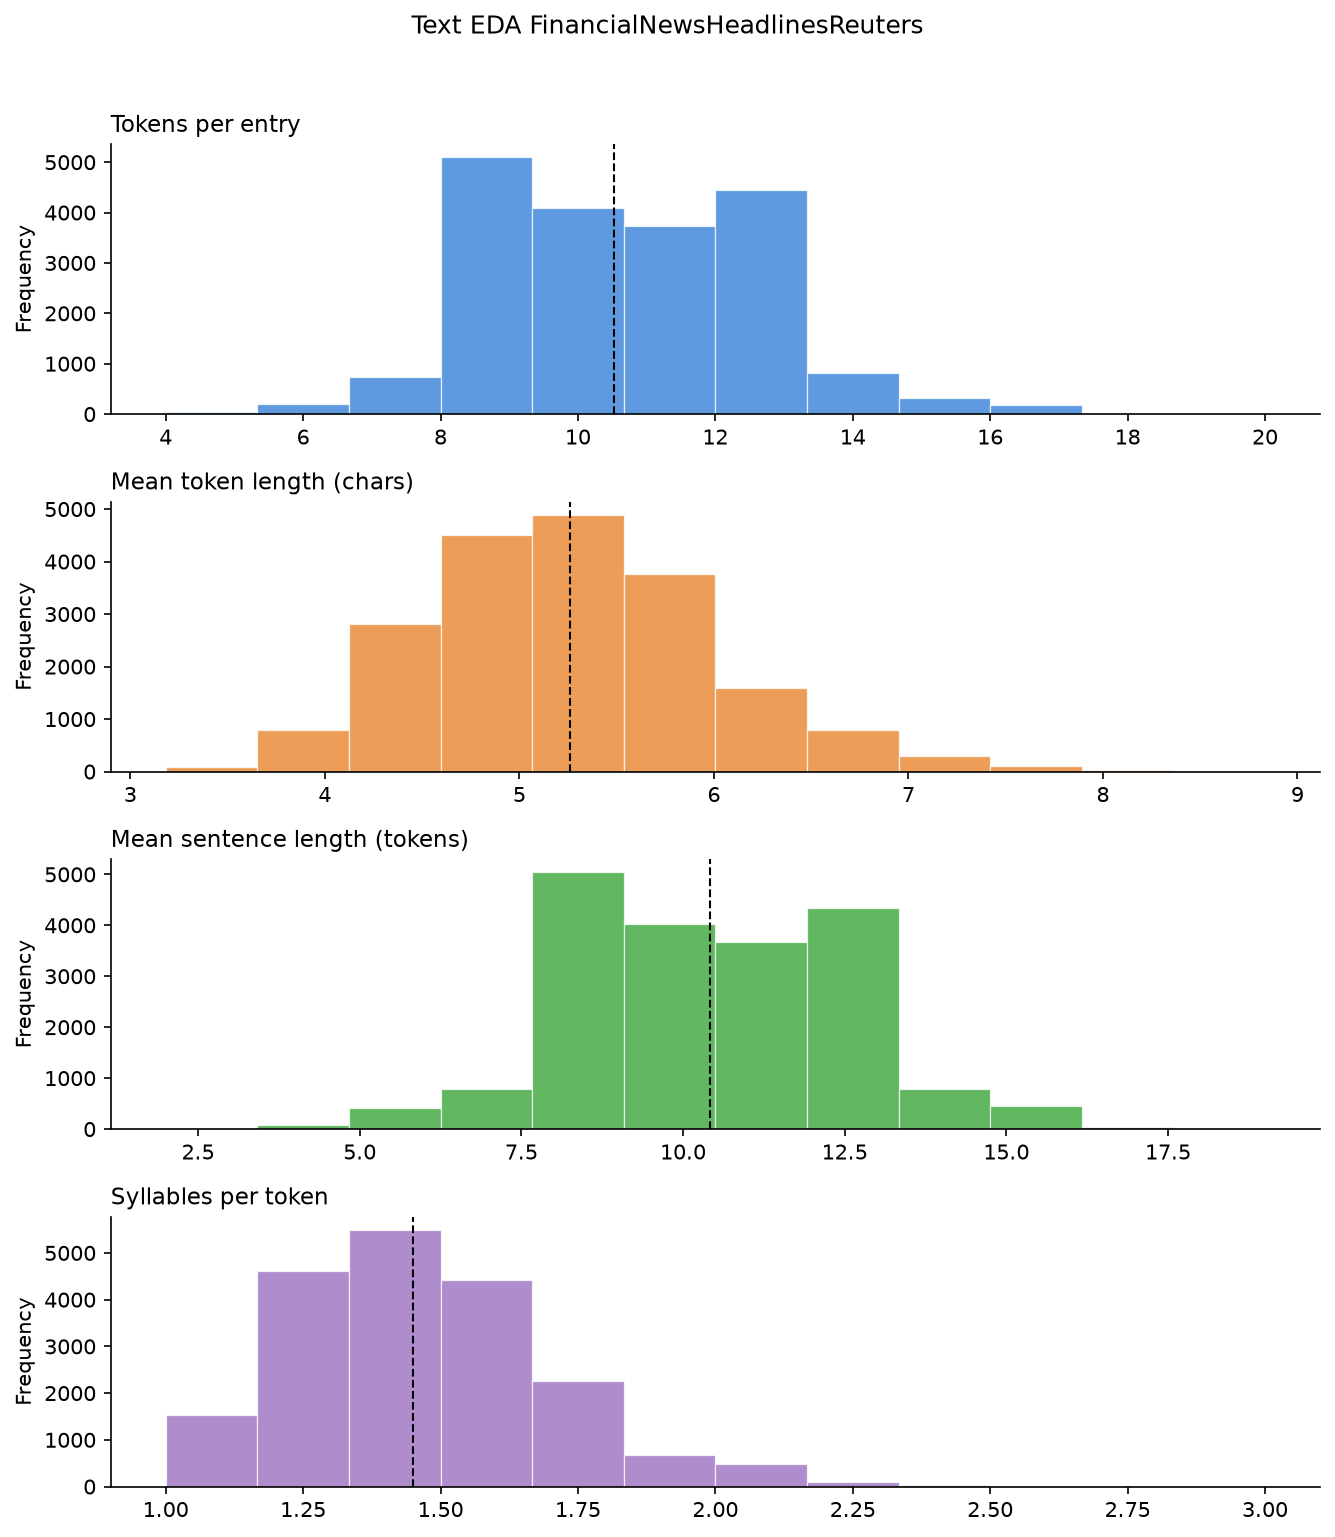

In [ ]:
# text characteristics for train dataset headlines

nlp = spacy.load("en_core_web_sm")
nlp.add_pipe("textdescriptives/descriptive_stats")

docs = list(nlp.pipe(df_headlines["Headlines"]))

text_metrics_headlines = td.extract_df(
    docs,
    metrics=["descriptive_stats"]
)

METRICS = [
    "n_tokens",
    "token_length_mean",
    "sentence_length_mean",
    "syllables_per_token_mean"
]

TITLES = {
    "n_tokens": "Tokens per entry",
    "token_length_mean": "Mean token length (chars)",
    "sentence_length_mean": "Mean sentence length (tokens)",
    "syllables_per_token_mean": "Syllables per token"
}

COLORS = ["#2a78d6", "#e67e22", "#2ca02c", "#9467bd"]

fig, axes = plt.subplots(4, 1, figsize=(9, 10), dpi=150)

fig.suptitle(
    "Text EDA FinancialNewsHeadlinesReuters",
    y=1.02
)

for ax, m, color in zip(axes, METRICS, COLORS):
    vals = text_metrics_headlines[m].dropna()

    ax.hist(
        vals,
        bins=12,
        color=color,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.6
    )

    # Mean
    ax.axvline(
        vals.mean(),
        color="black",
        linewidth=1,
        linestyle="--"
    )

    ax.set_title(TITLES[m], fontsize=11, loc="left")
    ax.set_ylabel("Frequency")
    
    # Clean up
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

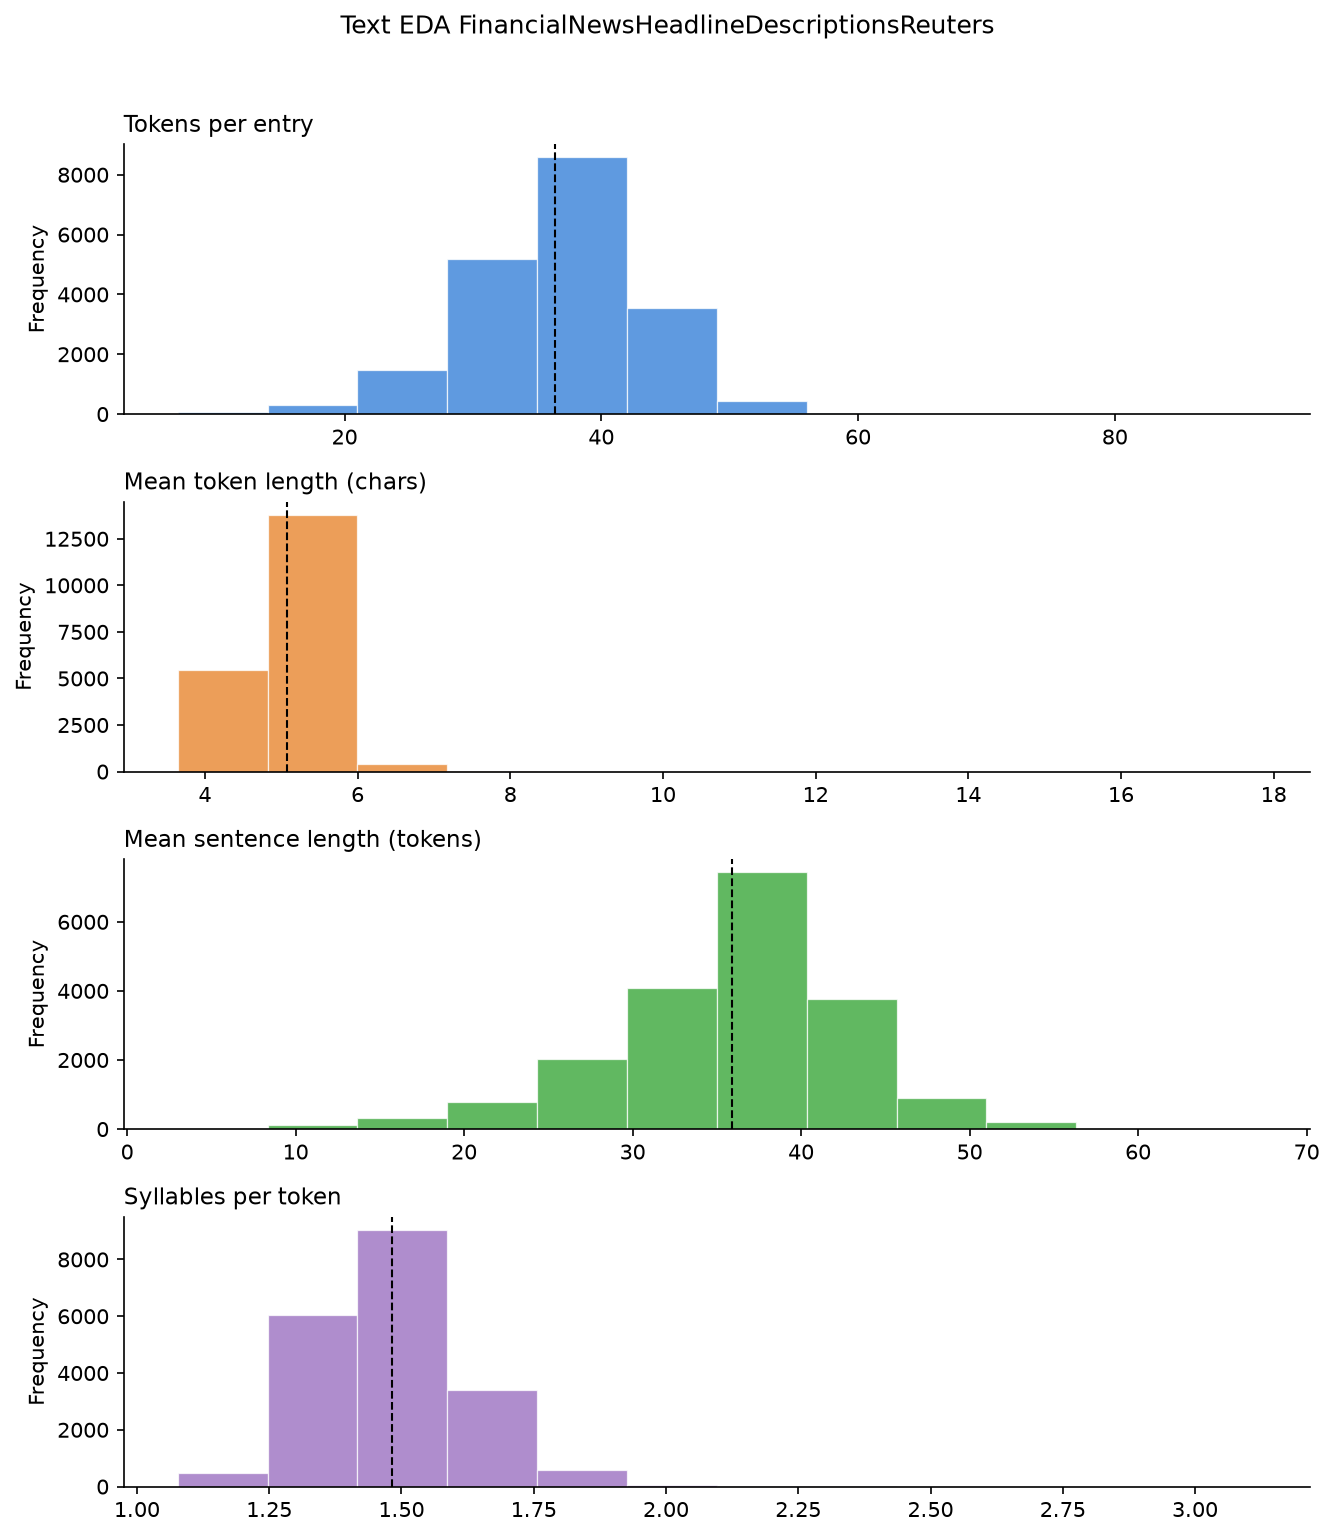

In [38]:
# text characteristics for train dataset headline descriptions

nlp = spacy.load("en_core_web_sm")
nlp.add_pipe("textdescriptives/descriptive_stats")

docs = list(nlp.pipe(df_desc["Description"]))

text_metrics_desc = td.extract_df(
    docs,
    metrics=["descriptive_stats"]
)

METRICS = [
    "n_tokens",
    "token_length_mean",
    "sentence_length_mean",
    "syllables_per_token_mean"
]

TITLES = {
    "n_tokens": "Tokens per entry",
    "token_length_mean": "Mean token length (chars)",
    "sentence_length_mean": "Mean sentence length (tokens)",
    "syllables_per_token_mean": "Syllables per token"
}

COLORS = ["#2a78d6", "#e67e22", "#2ca02c", "#9467bd"]

fig, axes = plt.subplots(4, 1, figsize=(9, 10), dpi=150)

fig.suptitle(
    "Text EDA FinancialNewsHeadlineDescriptionsReuters",
    y=1.02
)

for ax, m, color in zip(axes, METRICS, COLORS):
    vals = text_metrics_desc[m].dropna()

    ax.hist(
        vals,
        bins=12,
        color=color,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.6
    )

    # Mean
    ax.axvline(
        vals.mean(),
        color="black",
        linewidth=1,
        linestyle="--"
    )

    ax.set_title(TITLES[m], fontsize=11, loc="left")
    ax.set_ylabel("Frequency")
    
    # Clean up
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()